# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import alpha_diversity
from scipy.stats import mannwhitneyu
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import numpy as np
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa
import seaborn as sns
from itertools import combinations
from skbio.stats.distance import permanova
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")
    
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      facecolor=facecolor,
                      **kwargs)
    
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)
    
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

def get_significance_label(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

def annotate_within_category_pvalues(ax, long_df, x_col, y_col, hue_col, order, hue_order):
    """
    For each x category (e.g., Bacteria/Fungi/Virus), run Mann–Whitney U between two hue groups (RA vs OA)
    and annotate a bracket + significance label.
    """
    # assumes exactly two groups in hue_order (e.g., ['RA','OA'])
    g1, g2 = hue_order[0], hue_order[1]

    for i, cat in enumerate(order):
        sub = long_df[long_df[x_col] == cat]
        d1 = sub[sub[hue_col] == g1][y_col].dropna()
        d2 = sub[sub[hue_col] == g2][y_col].dropna()

        if len(d1) == 0 or len(d2) == 0:
            sig_label = "na"
            p_value = float("nan")
        else:
            _, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
            sig_label = get_significance_label(p_value)

        # bracket placement
        y_max = sub[y_col].max()
        y = y_max * 1.08
        h = y_max * 0.03 if y_max != 0 else 0.03

        # draw a small bracket centered at category tick
        x_center = i
        x1, x2 = x_center - 0.20, x_center + 0.20
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
        ax.text(x_center, y + h, sig_label, ha='center', va='bottom', fontsize=7, color='black')

        # optional: print p-values
        print(f"Mann-Whitney U for {cat}: p = {p_value:.4g}")

In [2]:
def clr_transform(X, pseudocount=1e-6):
    """
    Centered log-ratio transform for compositional data (rows = samples).
    Adds pseudocount, converts to relative abundances, logs, and centers by row mean.
    Returns a DataFrame with same index/columns.
    """
    X = X.astype(float).clip(lower=0) + pseudocount
    # avoid division by zero
    row_sums = X.sum(axis=1).replace(0, np.nan)
    X_rel = X.div(row_sums, axis=0).fillna(pseudocount / X.shape[1])
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = pd.DataFrame(np.nan_to_num(clrX, nan=0.0, posinf=0.0, neginf=0.0),
                        index=X.index, columns=X.columns)
    # clamp extreme values for numerical stability
    clrX = clrX.clip(lower=-50, upper=50)
    return clrX

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Set the global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Data

In [ ]:
bacteria_matrix = pd.read_csv("./99_Original_Data/bacteria_final_normalized_count.tsv", sep='\t', index_col=0)  
metadata = pd.read_csv("./01_Processed_Data/cleaned_metadata.tsv", sep='\t', index_col=1)
ra_metadata = pd.read_csv("./01_Processed_Data/cleaned_metadata_RA.tsv", sep='\t', index_col=0)
bacteria_matrix.fillna(0, inplace=True)
bacteria_matrix_before_filtering = pd.read_csv("./99_Original_Data/bacteria_unfiltered_count.tsv", sep='\t', index_col=0).transpose()  # Transpose to have samples as rows
metadata['diagnosis'] = metadata['diagnosis'].replace({'Non_RA': 'OA'})
metadata = metadata.merge(ra_metadata['Responder_Status'], left_index=True, right_index=True, how='left')
ra_vs_oa_maaslin2 = pd.read_csv("./99_Original_Data/maaslin2_OAvsRA/all_results.tsv", sep='\t')
r_vs_oa_maaslin2 = pd.read_csv("./99_Original_Data/maaslin2_OA_vs_Responder/all_results.tsv", sep='\t')
nr_vs_oa_maaslin2 = pd.read_csv("./99_Original_Data/maaslin2_OA_vs_NonResponder/all_results.tsv", sep='\t')

# Analysis

## Figure 2A

/tmp/ipykernel_3794134/776750963.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y='shannon', data=alpha_df, order=group_order, palette=palette, width=0.6, ax=ax)


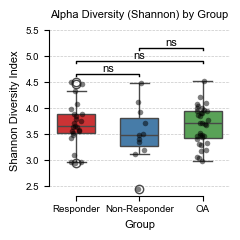

,group_1,group_2,n1,n2,median_1,median_2,stat,p_value,sig_label
0,Responder,Non-Responder,24,11,3.653018,3.484716,161.0,0.311202,ns
1,Responder,OA,24,34,3.653018,3.711195,410.0,0.981107,ns
2,Non-Responder,OA,11,34,3.484716,3.711195,157.0,0.435916,ns


In [5]:
from itertools import combinations
from scipy.stats import mannwhitneyu

# Alpha diversity calculation for three groups: OA, Responder, Non-Responder
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Prepare samples
common_samples = metadata.index.intersection(bacteria_matrix_before_filtering.index)
meta_sub = metadata.loc[common_samples]
mat = bacteria_matrix_before_filtering.loc[common_samples].astype(float)
responder_col = 'Responder_Status'  # Column name for responder status in metadata
# make relative abundance matrix (if not already normalized)

# Calculate alpha diversity (Shannon index)
alpha_div = alpha_diversity('shannon', mat.values, ids=mat.index)
oa_idx = meta_sub[meta_sub['diagnosis'] == 'OA'].index.tolist()
resp_vals = meta_sub[responder_col].astype(str).str.lower().str.replace(r'[\s_-]', '', regex=True)
resp_idx = meta_sub[resp_vals.isin(['responder','r','yes','y','true','1'])].index.tolist()
nonresp_idx = meta_sub[resp_vals.isin(['nonresponder','nonres','nr','n','no','false','0'])].index.tolist()

# Create grouping
grouping = meta_sub['diagnosis'].astype(str).copy()
grouping.loc[grouping.index.isin(resp_idx)] = 'Responder'
grouping.loc[grouping.index.isin(nonresp_idx)] = 'Non-Responder'
grouping.loc[grouping.index.isin(oa_idx)] = 'OA'

# Create dataframe for plotting
alpha_df = pd.DataFrame({
    'sample': alpha_div.index,
    'shannon': alpha_div.values,
    'group': grouping.values
})

# Pairwise Mann-Whitney U tests (Wilcoxon rank-sum test)
group_order = ['Responder', 'Non-Responder', 'OA']
pairwise_alpha = []

for g1, g2 in combinations(group_order, 2):
    d1 = alpha_df[alpha_df['group'] == g1]['shannon'].values
    d2 = alpha_df[alpha_df['group'] == g2]['shannon'].values
    
    stat, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
    sig_label = get_significance_label(p_value) # 기존 환경에 정의된 함수 사용
    
    pairwise_alpha.append({
        'group_1': g1,
        'group_2': g2,
        'n1': len(d1),
        'n2': len(d2),
        'median_1': np.median(d1),
        'median_2': np.median(d2),
        'stat': stat,
        'p_value': p_value,
        'sig_label': sig_label
    })

pairwise_alpha_df = pd.DataFrame(pairwise_alpha)

# Plot
fig, ax = plt.subplots(figsize=(2.5, 2.5)) # 브라켓이 들어가면 높이를 조금 더 키우는 것도 좋습니다 (예: 3, 4)
palette = dict(zip(group_order, sns.color_palette("Set1", n_colors=3)))

# Set color for each group OA: green, Responder: Red, Non-Responder: Blue
# palette = {'OA': 'green', 'Responder': 'red', 'Non-Responder': 'blue'}

sns.boxplot(x='group', y='shannon', data=alpha_df, order=group_order, palette=palette, width=0.6, ax=ax)
sns.stripplot(x='group', y='shannon', data=alpha_df, order=group_order, color='black', alpha=0.5, size=4, ax=ax)

# =====================================================================
# ★ 추가된 부분: Wilcoxon rank-sum test(Mann-Whitney U) 브라켓 그리기
# =====================================================================
# x축 좌표 매핑
x_coords = {group: i for i, group in enumerate(group_order)}

y_max = alpha_df['shannon'].max()
y_range = alpha_df['shannon'].max() - alpha_df['shannon'].min()

# 브라켓 위치 조정을 위한 파라미터
y_start = y_max + (y_range * 0.05) # 첫 브라켓 시작 높이
h = y_range * 0.02                 # 브라켓 꺾이는 부분의 높이(다리 길이)
step = y_range * 0.12              # 쌓이는 브라켓 간의 간격

# (선택) p-value가 유의미한 것만 그리고 싶다면 아래 반복문에 조건문 추가
# 브라켓을 순차적으로 위로 쌓아가며 그립니다
for i, row in pairwise_alpha_df.iterrows():
    # 유의미한 경우만 브라켓을 그리고 싶다면 아래 주석을 해제하세요.
    # if row['p_value'] >= 0.05: continue 
    
    x1, x2 = x_coords[row['group_1']], x_coords[row['group_2']]
    y = y_start + (i * step)
    
    # ㄷ자 모양 브라켓 라인 그리기
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.0, color='black')
    
    # 유의성 라벨 텍스트 추가 (별표 또는 ns)
    ax.text((x1+x2)*.5, y+h, row['sig_label'], ha='center', va='bottom', color='black', fontsize=8)

# 브라켓이 잘리지 않도록 y축 최댓값 넉넉하게 재조정
ax.set_ylim(top=y_start + (len(pairwise_alpha_df) * step) + (y_range * 0.1))
# =====================================================================

ax.set_xlabel('Group', fontsize=8)
ax.set_ylabel('Shannon Diversity Index', fontsize=8)
ax.set_title('Alpha Diversity (Shannon) by Group', fontsize=8)
# add up grid lines for better readability
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='x', labelsize=7)
ax.tick_params(axis='y', labelsize=7)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_2A.pdf", dpi=300, bbox_inches='tight')
plt.show()

display(pairwise_alpha_df)


## Figure 2B

Number of OA samples: 34
Number of Non-responder samples: 11
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      45
number of groups                  2
test statistic             1.369213
p-value                      0.0445
number of permutations         9999
Name: PERMANOVA results, dtype: object
R²: 3.09%


/tmp/ipykernel_3794134/3668184706.py:86: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f"PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)", fontsize=7)
/tmp/ipykernel_3794134/3668184706.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_ylabel(f"PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)", fontsize=7)


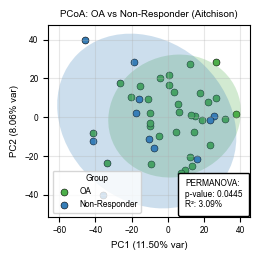

In [9]:
responder_col = 'Responder_Status'

# --- align samples ---
common_samples = metadata.index.intersection(bacteria_matrix_before_filtering.index)
meta_sub = metadata.loc[common_samples].copy()
mat = bacteria_matrix_before_filtering.loc[common_samples].astype(float)

# total-sum scaling (relative abundance)
mat = mat.div(mat.sum(axis=1), axis=0)

# --- identify the two groups: OA and Non-Responder ---
oa_idx = meta_sub[meta_sub['diagnosis'] == 'OA'].index.tolist()

# normalize responder labels; strip spaces/underscores/hyphens/slashes
resp_vals = (meta_sub[responder_col].astype(str)
             .str.lower()
             .str.replace(r'[\s_/-]', '', regex=True))

nonresp_tokens = {'nonresponder', 'nonres', 'nr', 'n', 'no', 'false', '0',
                  'moderateno', 'moderate'}   # 'Moderate/No' -> 'moderateno'
nonresp_idx = meta_sub[resp_vals.isin(nonresp_tokens)].index.tolist()
nonresp_idx = [i for i in nonresp_idx if i not in set(oa_idx)]  # OA never doubles as patient

print(f"Number of OA samples: {len(oa_idx)}")
print(f"Number of Non-responder samples: {len(nonresp_idx)}")

if len(oa_idx) == 0:
    raise ValueError("No OA samples found after intersection.")
if len(nonresp_idx) == 0:
    raise ValueError("No Non-responder samples detected — check Responder_Status values.")

# --- subset matrix to just these two groups ---
seen = set()
group_ids = [i for i in oa_idx + nonresp_idx if not (i in seen or seen.add(i))]
mat_subset = mat.loc[group_ids]

# --- Aitchison distance (CLR + Euclidean) ---
clr_mat = clr_transform(mat_subset)
dist = pdist(clr_mat.values, metric='euclidean')
distance_matrix = DistanceMatrix(squareform(dist), ids=clr_mat.index)

# --- grouping vector ---
grouping = pd.Series(index=clr_mat.index, dtype=object, name='group')   # <- name added
grouping.loc[grouping.index.isin(oa_idx)] = 'OA'
grouping.loc[grouping.index.isin(nonresp_idx)] = 'Non-Responder'

grouping = grouping.reindex(distance_matrix.ids)   # match DM id order; surfaces any stray NaN

# --- PERMANOVA (OA vs Non-Responder) ---
permanova_results = permanova(distance_matrix, grouping, permutations=9999)

n = distance_matrix.shape[0]
g = grouping.nunique()
F_stat = float(permanova_results["test statistic"])
r2 = (1 / (1 + (n - g) / ((g - 1) * F_stat))) * 100 if g > 1 and F_stat > 0 else np.nan

print(permanova_results)
print(f"R²: {r2:.2f}%")

# --- PCoA ---
pcoa_results = pcoa(distance_matrix)
pcoa_df = pcoa_results.samples.iloc[:, :2].copy()
pcoa_df.columns = ["PC1", "PC2"]
pcoa_df["group"] = grouping.values

fig, ax = plt.subplots(figsize=(2.7, 2.7))
group_order = [grp for grp in ["OA", "Non-Responder"] if grp in pcoa_df["group"].unique()]

set1 = sns.color_palette("Set1")
palette = {"OA": set1[2], "Non-Responder": set1[1]}   # OA=green, Non-Responder=blue

for grp in group_order:
    group_df = pcoa_df[pcoa_df["group"] == grp]
    sns.scatterplot(
        data=group_df, x="PC1", y="PC2",
        s=25, color=palette[grp], alpha=1,
        edgecolor="k", ax=ax, label=grp
    )
    if len(group_df) > 2:
        confidence_ellipse(
            group_df["PC1"], group_df["PC2"], ax,
            n_std=2, facecolor=palette[grp], alpha=0.25,
            edgecolor=palette[grp], linewidth=0
        )

ax.set_xlabel(f"PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)", fontsize=7)
ax.set_ylabel(f"PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)", fontsize=7)
ax.set_title("PCoA: OA vs Non-Responder (Aitchison)", fontsize=7)
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.grid(alpha=0.3)
ax.legend(title="Group", fontsize=6, title_fontsize=6, loc="lower left", frameon=True)

stats_text = (
    f"PERMANOVA:\n"
    f"p-value: {permanova_results['p-value']:.3g}\n"
    f"R²: {r2:.2f}%"
)
at = AnchoredText(stats_text, prop=dict(size=6), frameon=True, loc="lower right")
at.patch.set_boxstyle("round,pad=0.4,rounding_size=0.2")
at.patch.set_alpha(1)
ax.add_artist(at)

plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_2B_OA_vs_NonResponder.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 2C

#OA=34, #Resp=24, #NonResp=11
Mann-Whitney U (Aitchison, one-tailed 'less'): stat=133806.0000, p=0.0003209


/tmp/ipykernel_3794134/3565882981.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='comparison', y='distance', data=df_plot, palette=['#4C72B0','#DD8452'], width=0.2, fliersize=0)
/tmp/ipykernel_3794134/3565882981.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_3794134/3565882981.py:66: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method='scott'`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  ax = sns.violinplot(


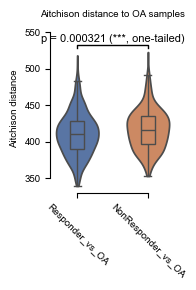

In [10]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Prepare samples & matrices
common_samples = metadata.index.intersection(bacteria_matrix_before_filtering.index)
meta_sub = metadata.loc[common_samples]
mat = bacteria_matrix_before_filtering.loc[common_samples].astype(float)

# choose responder list if available
resp_list = resp_idx_list if 'resp_idx_list' in globals() else (resp_idx if 'resp_idx' in globals() else [])
# compute non-responder indices from metadata
resp_vals_sub = meta_sub[responder_col].astype(str).str.lower().str.replace(r'[\s_-]', '', regex=True)
nonresp_idx = meta_sub[resp_vals_sub.isin(['nonresponder','nonres','nr','n','no','false','0'])].index.tolist()
oa_idx = meta_sub[meta_sub['diagnosis'] == 'OA'].index.tolist()

def clr_transform(X, pseudocount=1e-6):
    """
    Centered log-ratio transform for compositional data (rows = samples).
    Adds pseudocount, converts to relative abundances, logs, and centers by row mean.
    Returns a DataFrame with same index/columns.
    """
    X = X.astype(float).clip(lower=0) + pseudocount
    # avoid division by zero
    row_sums = X.sum(axis=1).replace(0, np.nan)
    X_rel = X.div(row_sums, axis=0).fillna(pseudocount / X.shape[1])
    logX = np.log(X_rel)
    row_means = logX.mean(axis=1)
    clrX = logX.sub(row_means, axis=0)
    clrX = pd.DataFrame(np.nan_to_num(clrX, nan=0.0, posinf=0.0, neginf=0.0),
                        index=X.index, columns=X.columns)
    # clamp extreme values for numerical stability
    clrX = clrX.clip(lower=-50, upper=50)
    return clrX

# perform CLR on the bacteria matrix
clr_mat = clr_transform(mat, pseudocount=1e-6)

def pairwise_aitchison(rows_a, rows_b):
    if len(rows_a) == 0 or len(rows_b) == 0:
        return np.array([])
    return cdist(clr_mat.loc[rows_a].values, clr_mat.loc[rows_b].values, metric='euclidean').ravel()

d_resp_oa = pairwise_aitchison(resp_list, oa_idx)
d_nonresp_oa = pairwise_aitchison(nonresp_idx, oa_idx)

print(f"#OA={len(oa_idx)}, #Resp={len(resp_list)}, #NonResp={len(nonresp_idx)}")
if d_resp_oa.size == 0 or d_nonresp_oa.size == 0:
    raise ValueError("One of the Aitchison distance groups is empty; cannot compare.")

# One-tailed Wilcoxon rank-sum (Mann-Whitney U) test
# H1: Responder-to-OA distances are smaller than NonResponder-to-OA distances
# (i.e., responders' microbiomes are more OA-like / "healthier")
stat, p_value = mannwhitneyu(d_resp_oa, d_nonresp_oa, alternative='less')
print(f"Mann-Whitney U (Aitchison, one-tailed 'less'): stat={stat:.4f}, p={p_value:.4g}")

# Plot
df_plot = pd.DataFrame({
    'comparison': np.concatenate([
        np.repeat('Responder_vs_OA', d_resp_oa.size),
        np.repeat('NonResponder_vs_OA', d_nonresp_oa.size)
    ]),
    'distance': np.concatenate([d_resp_oa, d_nonresp_oa])
})

plt.figure(figsize=(2,3))
ax = sns.boxplot(x='comparison', y='distance', data=df_plot, palette=['#4C72B0','#DD8452'], width=0.2, fliersize=0)
ax = sns.violinplot(
    x='comparison', y='distance', data=df_plot,
    palette=['#4C72B0', '#DD8452'],
    order=['Responder_vs_OA', 'NonResponder_vs_OA'],
    cut=0, bw='scott', width=0.6, inner=None, ax=plt.gca()
)

y_max = df_plot['distance'].max()
y_min = df_plot['distance'].min()
y_range = y_max - y_min

# Bracket height and tick depth (tune these to your data scale)
bracket_y = y_max + 0.05 * y_range
tick_drop = 0.02 * y_range

# Draw the bracket: left tick -> horizontal line -> right tick
x1, x2 = 0, 1  # x-positions of the two violins
ax.plot(
    [x1, x1, x2, x2],
    [bracket_y - tick_drop, bracket_y, bracket_y, bracket_y - tick_drop],
    lw=1.0, c='black'
)

# Label above the bracket
sig_label = get_significance_label(p_value)
ax.text(
    (x1 + x2) / 2, bracket_y + 0.01 * y_range,
    f"p = {p_value:.3g} ({sig_label}, one-tailed)",
    ha='center', va='bottom', fontsize=8
)

# Make sure the bracket + label aren't clipped
ax.set_ylim(top=bracket_y + 0.15 * y_range)
sig_label = get_significance_label(p_value)

ax.set_xlabel('')
ax.set_title('Aitchison distance to OA samples', fontsize=7)
ax.set_ylabel('Aitchison distance', fontsize=7)
ax.tick_params(axis='x', labelsize=7, rotation=315)
ax.tick_params(axis='y', labelsize=7)
sns.despine(trim=True)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_2C.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 2D

Plotting 5 significant features...


/tmp/ipykernel_3794134/3360945474.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


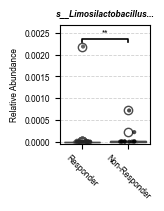

/tmp/ipykernel_3794134/3360945474.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


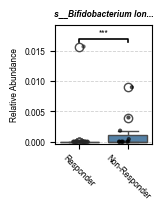

/tmp/ipykernel_3794134/3360945474.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


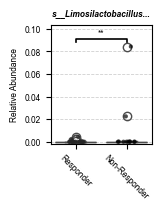

/tmp/ipykernel_3794134/3360945474.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


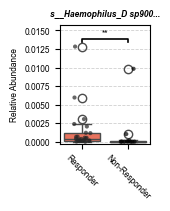

/tmp/ipykernel_3794134/3360945474.py:75: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


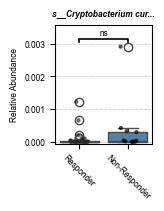

In [12]:
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract significant features and correct their names
# MaAsLin2 replaces spaces with dots; this changes them back to match bacteria_matrix
maaslin_sig_features = sig_points["feature"].tolist()
matrix_sig_features = [feat.replace(".", " ") for feat in maaslin_sig_features]

print(f"Plotting {len(matrix_sig_features)} significant features...")

# 2. Prepare the abundance data
# Use common samples to align metadata and matrix
common_samples = metadata.index.intersection(bacteria_matrix.index)
meta_sub = metadata.loc[common_samples].copy()

# Calculate Relative Abundance (Total-Sum Scaling)
mat = bacteria_matrix.loc[common_samples].astype(float)
mat_rel = mat.div(mat.sum(axis=1), axis=0)

# Filter to only keep the significant features that actually exist in the matrix
valid_features = [feat for feat in matrix_sig_features if feat in mat_rel.columns]

if len(valid_features) < len(matrix_sig_features):
    missing = set(matrix_sig_features) - set(valid_features)
    print(f"Warning: Could not find these features in bacteria_matrix: {missing}")

# 3. Combine metadata and abundance data for plotting
plot_df = pd.concat([meta_sub['Responder_Status'], mat_rel[valid_features]], axis=1)
plot_df = plot_df.dropna(subset=['Responder_Status'])

# Define groups and colors
order = ['Responder', 'Non-Responder']  # Update these if your responder labels are different
custom_palette = ['#FF6347', '#4682B4']  # Tomato, SteelBlue

def get_significance_label(p_value):
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

# 4. Loop through each significant feature and create a boxplot
for feat in valid_features:
    fig, ax = plt.subplots(figsize=(1.5, 2), constrained_layout=True)
    
    # Extract data for the two groups
    d1 = plot_df[plot_df['Responder_Status'] == order[0]][feat].dropna()
    d2 = plot_df[plot_df['Responder_Status'] == order[1]][feat].dropna()
    
    # Skip if a group has no data
    if len(d1) == 0 or len(d2) == 0:
        print(f"Skipping {feat} due to missing data in one of the groups.")
        plt.close(fig)
        continue
        
    # Mann-Whitney U test
    _, p_value = mannwhitneyu(d1, d2, alternative='two-sided')
    sig_label = get_significance_label(p_value)
    
    # Boxplot
    sns.boxplot(
        data=plot_df,
        x='Responder_Status',
        y=feat,
        hue='Responder_Status',
        hue_order=order,
        order=order,
        palette=custom_palette,
        legend=False,
        ax=ax
    )
    
    # Stripplot
    sns.stripplot(
        data=plot_df,
        x='Responder_Status',
        y=feat,
        hue='Responder_Status',
        hue_order=order,
        order=order,
        legend=False,
        jitter=0.18,
        size=3,
        color='black',
        alpha=0.7,
        ax=ax
    )
    
    # Formatting grid
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    ax.xaxis.grid(False)
    
    # Significance Bracket
    y_max = plot_df[feat].max()
    # Add a small buffer so the line doesn't sit exactly on the top dot
    y = y_max + (y_max * 0.05) if y_max != 0 else 0.05
    h = y_max * 0.03 if y_max != 0 else 0.01
    x1, x2 = 0, 1
    
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
    ax.text((x1 + x2) / 2, y + h + (h * 0.5), sig_label, 
            ha='center', va='bottom', fontsize=6, color='black')
    
    # Expand Y-axis so bracket isn't cropped
    ax.set_ylim(bottom=-(y_max * 0.02), top=y + h + (y_max * 0.15))
    
    # Labels and Titles
    ax.set_ylabel('Relative Abundance', fontsize=6)
    ax.set_xlabel('', fontsize=6)
    ax.tick_params(axis='x', labelsize=6, rotation=315)
    ax.tick_params(axis='y', labelsize=6)
    
    # Truncate title if the bug name is too long for the small plot
    title_name = feat if len(feat) < 25 else feat[:22] + "..."
    plt.title(title_name, fontsize=6, style='italic', weight='bold')
    
    # Save figure (Optional: dynamically name the file based on the feature)
    safe_filename = feat.replace(" ", "_").replace("/", "_")
    plt.savefig(f'./03_Output_Figures/Boxplot_{safe_filename}.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()

## Figure 2E

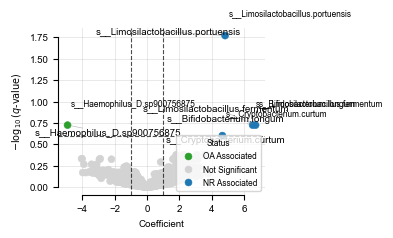

Total tested (Comparison_Group): 1169
Significant features: 5


,feature,value,coef,qval
0,s__Limosilactobacillus.portuensis,Non-Responder,4.822932,0.016949
1,s__Bifidobacterium.longum,Non-Responder,6.526676,0.188449
2,s__Limosilactobacillus.fermentum,Non-Responder,6.707311,0.188449
3,s__Haemophilus_D.sp900756875,Non-Responder,-4.907575,0.188449
6,s__Cryptobacterium.curtum,Non-Responder,4.654011,0.249727


In [11]:
from adjustText import adjust_text

# Volcano plot: MaAsLin2 OA vs Non-Responder (metadata == "Comparison_Group")
vol_df = nr_vs_oa_maaslin2.copy()
vol_df = vol_df[vol_df["metadata"] == "Comparison_Group"].copy()

# Ensure numeric
vol_df["coef"] = pd.to_numeric(vol_df["coef"], errors="coerce")
vol_df["qval"] = pd.to_numeric(vol_df["qval"], errors="coerce")
vol_df = vol_df.dropna(subset=["coef", "qval"]).copy()

# Avoid -log10(0)
vol_df["qval_plot"] = vol_df["qval"].clip(lower=1e-300)
vol_df["neg_log10_qval"] = -np.log10(vol_df["qval_plot"])

# 1 & 2. Create direction-specific significance categories for the legend
coef_thr = 1.0
q_thr = 0.25

def assign_status(row):
    if row["qval"] < q_thr:
        if row["coef"] > coef_thr:
            return "NR Associated"  # Significant Positive
        elif row["coef"] < -coef_thr:
            return "OA Associated"  # Significant Negative
    return "Not Significant"

vol_df["Status"] = vol_df.apply(assign_status, axis=1)

# Plot setup (slightly widened to accommodate labels nicely)
fig, ax = plt.subplots(figsize=(4, 2.5))

# Plot using the new status categories
sns.scatterplot(
    data=vol_df,
    x="coef",
    y="neg_log10_qval",
    hue="Status",
    hue_order=["OA Associated", "Not Significant", "NR Associated"],
    palette={
        "NR Associated": "#1F77B4",   # Blue
        "OA Associated": "#2CA02C",   # Green from set1
        "Not Significant": "lightgray"
    },
    alpha=1,
    s=25,
    edgecolor=None,
    ax=ax
)

# Threshold lines
ax.axvline(-coef_thr, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(coef_thr, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axhline(-np.log10(q_thr), color="black", linestyle="--", linewidth=0.8, alpha=0.7)

# 3. Labeling significant points with anti-overlap protection
sig_points = vol_df[vol_df["Status"] != "Not Significant"]
texts = []

# Fallback labeling (No installation required)
sig_points = vol_df[vol_df["Status"] != "Not Significant"]
for _, r in sig_points.iterrows():
    ax.text(
        r["coef"] + 0.2,          # Shifts text slightly to the right
        r["neg_log10_qval"] + 0.2, # Shifts text slightly upward
        r["feature"], 
        fontsize=6, 
        alpha=1,
        verticalalignment='bottom', 
        horizontalalignment='left'
    )

# Formatting polish
ax.set_xlabel("Coefficient", fontsize=7)
ax.set_ylabel(r"$-\log_{10}(q\text{-value})$", fontsize=7)
ax.tick_params(axis="both", labelsize=7)

# --- grid (점 뒤에 깔리도록) ---
ax.set_axisbelow(True)
ax.grid(True, which="major", linestyle="-", linewidth=0.4, alpha=0.3, color="gray")

for _, r in sig_points.iterrows():
    texts.append(
        ax.text(
            r["coef"], 
            r["neg_log10_qval"], 
            r["feature"], 
            fontsize=7, 
            weight="medium"
        )
    )

# Automatically push labels away from each other and away from points
if texts:
    adjust_text(
        texts, 
        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5, linewidth=0.5),
        expand=(1.2, 1.4), # dict-like layout expansion factor
        ax=ax
    )
ax.legend(title="Status", fontsize=6, title_fontsize=6, loc="lower right", frameon=True)

sns.despine(trim=True)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_2E.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Console printouts remain unchanged
print(f"Total tested (Comparison_Group): {len(vol_df)}")
print(f"Significant features: {len(sig_points)}")
display(sig_points.sort_values("qval")[["feature", "value", "coef", "qval"]].head(30))

## Figure 2F

/tmp/ipykernel_3637550/3096614225.py:112: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


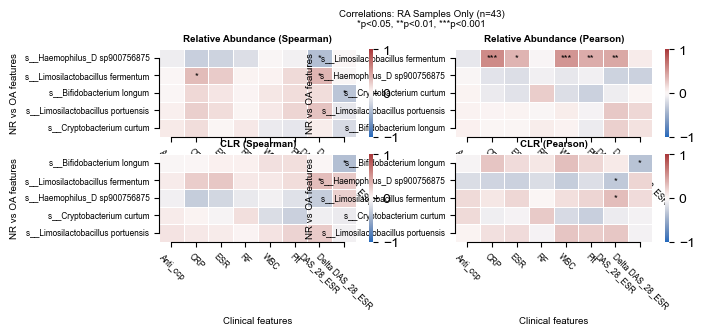


Relative Abundance (Spearman)
Correlation Coefficients (r):


,Anti_ccp,CRP,ESR,RF,WBC,Plt,DAS_28_ESR,Delta DAS_28_ESR
s__Limosilactobacillus portuensis,0.055610,0.224321,0.150543,0.023437,0.095487,0.193410,0.273762,-0.132319
s__Bifidobacterium longum,-0.000753,0.176536,0.115387,0.030554,0.101616,0.155517,0.149096,-0.336054
s__Limosilactobacillus fermentum,-0.000889,0.313591,0.241601,0.035507,0.045359,0.169341,0.348388,-0.027888
s__Haemophilus_D sp900756875,-0.096105,-0.275797,-0.253498,-0.186906,-0.025217,-0.073875,-0.376083,-0.011642
s__Cryptobacterium curtum,0.087392,0.155180,0.003485,0.100066,-0.109888,-0.139945,0.073900,-0.208672



P-Values:


,Anti_ccp,CRP,ESR,RF,WBC,Plt,DAS_28_ESR,Delta DAS_28_ESR
s__Limosilactobacillus portuensis,0.723197,0.148141,0.335248,0.881414,0.542464,0.213987,0.075669,0.448616
s__Bifidobacterium longum,0.996174,0.257453,0.461234,0.845787,0.516734,0.319338,0.339968,0.048411
s__Limosilactobacillus fermentum,0.995486,0.040586,0.118565,0.821167,0.772716,0.277662,0.022053,0.873648
s__Haemophilus_D sp900756875,0.539842,0.073434,0.100957,0.230092,0.872476,0.637782,0.012938,0.947080
s__Cryptobacterium curtum,0.577358,0.320403,0.982303,0.523184,0.483004,0.370759,0.637671,0.228982



Relative Abundance (Pearson)
Correlation Coefficients (r):


...

,Anti_ccp,CRP,ESR,RF,WBC,Plt,DAS_28_ESR,Delta DAS_28_ESR
s__Limosilactobacillus portuensis,0.436710,0.529043,0.605380,0.868924,0.445155,0.201005,0.122444,0.675213
s__Bifidobacterium longum,0.905895,0.941694,0.749051,0.738323,0.382395,0.367175,0.970479,0.024400
s__Limosilactobacillus fermentum,0.592732,0.136828,0.085930,0.525669,0.525115,0.328564,0.046263,0.148881
s__Haemophilus_D sp900756875,0.614846,0.057241,0.131845,0.449371,0.622109,0.273443,0.056208,0.215770
s__Cryptobacterium curtum,0.616616,0.823652,0.750147,0.356435,0.217514,0.082110,0.570194,0.515346



CLR (Pearson)
Correlation Coefficients (r):


,Anti_ccp,CRP,ESR,RF,WBC,Plt,DAS_28_ESR,Delta DAS_28_ESR
s__Limosilactobacillus portuensis,0.032879,0.134028,0.161996,-0.058850,0.273249,0.233013,0.262694,-0.067400
s__Bifidobacterium longum,-0.051887,0.266085,0.160658,0.102712,0.298330,0.186000,0.088049,-0.354072
s__Limosilactobacillus fermentum,0.167851,0.106428,0.180771,0.010787,0.143728,0.187621,0.311909,0.160865
s__Haemophilus_D sp900756875,-0.191602,-0.248893,-0.261998,-0.194754,-0.290738,-0.183482,-0.317275,0.194311
s__Cryptobacterium curtum,0.166993,-0.091247,-0.057981,0.242313,-0.209274,-0.273916,-0.106663,-0.064759



P-Values:


,Anti_ccp,CRP,ESR,RF,WBC,Plt,DAS_28_ESR,Delta DAS_28_ESR
s__Limosilactobacillus portuensis,0.834212,0.391525,0.299339,0.707766,0.076241,0.132651,0.088780,0.700457
s__Bifidobacterium longum,0.741066,0.084587,0.303403,0.512199,0.051999,0.232400,0.574486,0.036908
s__Limosilactobacillus fermentum,0.281973,0.496969,0.246028,0.945269,0.357834,0.228282,0.041734,0.355926
s__Haemophilus_D sp900756875,0.218384,0.107518,0.089658,0.210759,0.058571,0.238897,0.038162,0.263348
s__Cryptobacterium curtum,0.284477,0.560614,0.711891,0.117451,0.178035,0.075498,0.496016,0.711686


In [ ]:
from scipy.stats import spearmanr, pearsonr

# 1. Identify Significant Features (from NR vs OA comparison)
sig_features = (
    nr_vs_oa_maaslin2.loc[
        (nr_vs_oa_maaslin2["metadata"] == "Comparison_Group") &
        (nr_vs_oa_maaslin2["qval"] < 0.25),
        "feature"
    ]
    .dropna()
    .unique()
    .tolist()
)

# Preprocess feature names to match bacteria_matrix columns
sig_features = [f.replace('.', ' ') for f in sig_features]
sig_features = [f for f in sig_features if f in bacteria_matrix.columns]

# 2. Identify RA samples ONLY
# Adjust the column name "Diagnosis" if your metadata uses a different column (e.g., "Disease_State", "Group")
if "ra_idx" in globals():
    ra_samples = ra_idx
else:
    # Broad search across metadata for 'RA' or 'rheumatoid arthritis'
    ra_samples = metadata[
        metadata.astype(str).apply(lambda x: x.str.lower().str.contains("^ra$|rheumatoid arthritis")).any(axis=1)
    ].index.tolist()

common_samples = bacteria_matrix.index.intersection(ra_samples).intersection(metadata.index)

# 3. Subset Data (Relative Abundance & CLR)
X_ra = bacteria_matrix.loc[common_samples, sig_features].astype(float)
# Assuming you have a pre-defined clr_transform function
X_clr = clr_transform(X_ra) 

Y = metadata.loc[common_samples, ["Anti_ccp", "CRP", "ESR", "RF", "WBC", "Plt", "DAS_28_ESR", "Delta DAS_28_ESR"]].copy()
Y = Y.apply(pd.to_numeric, errors="coerce")

# 4. Helper function to compute correlations
def get_correlation_matrices(X_df, Y_df, method="spearman"):
    rho = pd.DataFrame(index=X_df.columns, columns=Y_df.columns, dtype=float)
    pval = pd.DataFrame(index=X_df.columns, columns=Y_df.columns, dtype=float)
    
    for feat in X_df.columns:
        for clin in Y_df.columns:
            tmp = pd.concat([X_df[feat], Y_df[clin]], axis=1).dropna()
            if tmp.shape[0] >= 3:
                if method == "spearman":
                    r, p = spearmanr(tmp.iloc[:, 0], tmp.iloc[:, 1])
                elif method == "pearson":
                    r, p = pearsonr(tmp.iloc[:, 0], tmp.iloc[:, 1])
            else:
                r, p = np.nan, np.nan
                
            rho.loc[feat, clin] = r
            pval.loc[feat, clin] = p
            
    return rho, pval

# 5. Calculate all combinations
configs = {
    "Relative Abundance (Spearman)": get_correlation_matrices(X_ra, Y, "spearman"),
    "Relative Abundance (Pearson)": get_correlation_matrices(X_ra, Y, "pearson"),
    "CLR (Spearman)": get_correlation_matrices(X_clr, Y, "spearman"),
    "CLR (Pearson)": get_correlation_matrices(X_clr, Y, "pearson"),
}

# Helper function to generate significance stars
def get_star_annotations(pval_df):
    annot = pd.DataFrame(index=pval_df.index, columns=pval_df.columns, data="")
    annot[pval_df < 0.05] = "*"
    annot[pval_df < 0.01] = "**"
    annot[pval_df < 0.001] = "***"
    annot[pval_df.isna()] = ""
    return annot

# 6. Plotting 2x2 Heatmap
fig, axes = plt.subplots(2, 2, figsize=(7, (0.5 * len(sig_features))))
axes = axes.flatten()

for i, (title, (rho, pval)) in enumerate(configs.items()):
    # Order features by strongest absolute correlation in the current matrix
    feature_order = rho.abs().max(axis=1).sort_values(ascending=False).index
    rho_ordered = rho.loc[feature_order]
    pval_ordered = pval.loc[feature_order]
    
    # Generate the string matrix of stars to overlay
    annot_stars = get_star_annotations(pval_ordered)
    
    sns.heatmap(
        rho_ordered,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.4,
        linecolor="white",
        # cbar_kws={"label": "Correlation coefficient"},
        annot=annot_stars,            
        fmt="",                       
        annot_kws={"size": 7, "color": "black", "ha": "center", "va": "center"}, 
        ax=axes[i]
    )
    axes[i].set_title(title, fontsize=7, weight="bold")
    axes[i].set_xlabel("Clinical features", fontsize=7)
    axes[i].set_ylabel("NR vs OA features", fontsize=7)
    axes[i].tick_params(axis='x', labelsize=6, rotation=315)
    axes[i].tick_params(axis='y', labelsize=6)
    sns.despine(ax=axes[i], trim=True)

plt.suptitle(f"Correlations: RA Samples Only (n={len(common_samples)})\n*p<0.05, **p<0.01, ***p<0.001", fontsize=7, y=1.04)
plt.tight_layout()
plt.savefig("./03_Output_Figures/Figure_2F.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 7. Display Results
for title, (rho, pval) in configs.items():
    print(f"\n{'='*50}\n{title}\n{'='*50}")
    print("Correlation Coefficients (r):")
    display(rho)
    print("\nP-Values:")
    display(pval)

## Supplementary figure 1

Number of OA samples: 34
Number of Responder samples: 24
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      58
number of groups                  2
test statistic             1.189836
p-value                      0.2485
number of permutations         9999
Name: PERMANOVA results, dtype: object
R²: 2.08%


/home/sebin595/miniforge3/envs/preprocessing/lib/python3.12/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.07426896608156379 and the largest is 3.632339912309722.
  warn(
/tmp/ipykernel_3637550/4161950437.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.set_xlabel(f"PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)", fontsize=7)
/tmp/ipykernel_3637550/4161950437.py:86: FutureWarning: Series.__getitem__ treat

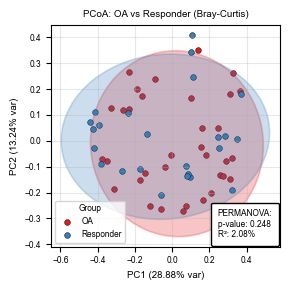

In [ ]:
responder_col = 'Responder_Status'

# --- align samples ---
common_samples = metadata.index.intersection(bacteria_matrix.index)
meta_sub = metadata.loc[common_samples].copy()
mat = bacteria_matrix.loc[common_samples].astype(float)

# total-sum scaling (relative abundance)
mat = mat.div(mat.sum(axis=1), axis=0)

# --- identify the two groups: OA and Responder ---
oa_idx = meta_sub[meta_sub['diagnosis'] == 'OA'].index.tolist()

# normalize responder labels; strip spaces/underscores/hyphens/slashes
resp_vals = (meta_sub[responder_col].astype(str)
             .str.lower()
             .str.replace(r'[\s_/-]', '', regex=True))

# Look for positive responder tokens (added 'good' based on your earlier code)
resp_tokens = {'responder', 'res', 'r', 'y', 'yes', 'true', '1', 'good'}
resp_group_idx = meta_sub[resp_vals.isin(resp_tokens)].index.tolist()
resp_group_idx = [i for i in resp_group_idx if i not in set(oa_idx)]  # OA never doubles as patient

print(f"Number of OA samples: {len(oa_idx)}")
print(f"Number of Responder samples: {len(resp_group_idx)}")

if len(oa_idx) == 0:
    raise ValueError("No OA samples found after intersection.")
if len(resp_group_idx) == 0:
    raise ValueError("No Responder samples detected — check Responder_Status values.")

# --- subset matrix to just these two groups ---
seen = set()
group_ids = [i for i in oa_idx + resp_group_idx if not (i in seen or seen.add(i))]
mat_subset = mat.loc[group_ids]

# --- Bray-Curtis distance ---
dist = pdist(mat_subset.values, metric='braycurtis')
distance_matrix = DistanceMatrix(squareform(dist), ids=mat_subset.index)

# --- grouping vector ---
grouping = pd.Series(index=mat_subset.index, dtype=object, name='group')
grouping.loc[grouping.index.isin(oa_idx)] = 'OA'
grouping.loc[grouping.index.isin(resp_group_idx)] = 'Responder'

grouping = grouping.reindex(distance_matrix.ids)   # match DM id order; surfaces any stray NaN

# --- PERMANOVA (OA vs Responder) ---
permanova_results = permanova(distance_matrix, grouping, permutations=9999)

n = distance_matrix.shape[0]
g = grouping.nunique()
F_stat = float(permanova_results["test statistic"])
r2 = (1 / (1 + (n - g) / ((g - 1) * F_stat))) * 100 if g > 1 and F_stat > 0 else np.nan

print(permanova_results)
print(f"R²: {r2:.2f}%")

# --- PCoA ---
pcoa_results = pcoa(distance_matrix)
pcoa_df = pcoa_results.samples.iloc[:, :2].copy()
pcoa_df.columns = ["PC1", "PC2"]
pcoa_df["group"] = grouping.values

fig, ax = plt.subplots(figsize=(3, 3))

# Updated group order for the new comparison
group_order = [grp for grp in ["OA", "Responder"] if grp in pcoa_df["group"].unique()]
palette = dict(zip(group_order, sns.color_palette("Set1", n_colors=len(group_order))))

for grp in group_order:
    group_df = pcoa_df[pcoa_df["group"] == grp]
    sns.scatterplot(
        data=group_df, x="PC1", y="PC2",
        s=17, color=palette[grp], alpha=1,
        edgecolor="k", ax=ax, label=grp
    )
    if len(group_df) > 2:
        confidence_ellipse(
            group_df["PC1"], group_df["PC2"], ax,
            n_std=2, facecolor=palette[grp], alpha=0.25,
            edgecolor=palette[grp], linewidth=1.2
        )

ax.set_xlabel(f"PC1 ({pcoa_results.proportion_explained[0]*100:.2f}% var)", fontsize=7)
ax.set_ylabel(f"PC2 ({pcoa_results.proportion_explained[1]*100:.2f}% var)", fontsize=7)
ax.set_title("PCoA: OA vs Responder (Bray-Curtis)", fontsize=7) # Updated title
ax.tick_params(axis="x", labelsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.grid(alpha=0.3)
ax.legend(title="Group", fontsize=6, title_fontsize=6, loc="lower left", frameon=True)

stats_text = (
    f"PERMANOVA:\n"
    f"p-value: {permanova_results['p-value']:.3g}\n"
    f"R²: {r2:.2f}%"
)
at = AnchoredText(stats_text, prop=dict(size=6), frameon=True, loc="lower right")
at.patch.set_boxstyle("round,pad=0.4,rounding_size=0.2")
at.patch.set_alpha(1)
ax.add_artist(at)

plt.tight_layout()
# Updated filename
plt.savefig("./03_Output_Figures/Figure_2B_OA_vs_Responder_BrayCurtis.pdf", dpi=300, bbox_inches='tight')
plt.show()